Processing common_2 from /Users/avshah/P_llm_auctions/llm-auction/experiment_logs/V10/common_spsb_2


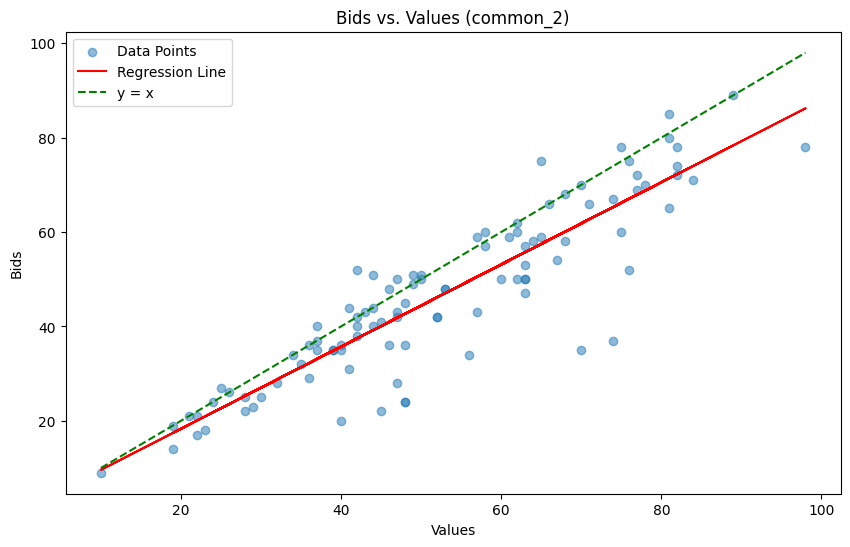

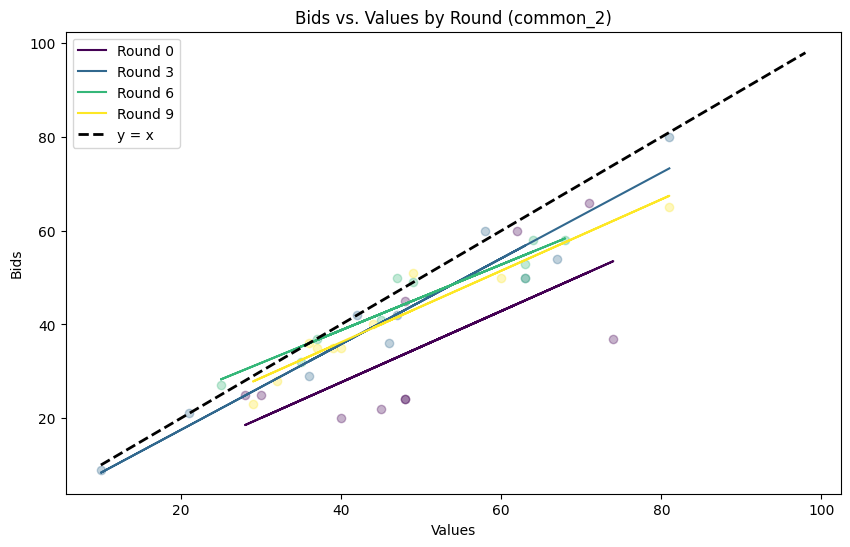

Processing common_3 from /Users/avshah/P_llm_auctions/llm-auction/experiment_logs/V10/common_spsb_3


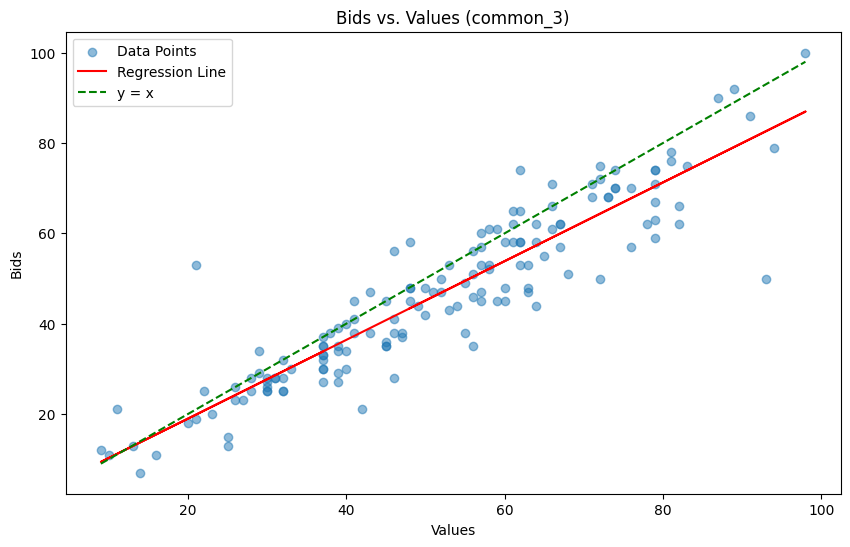

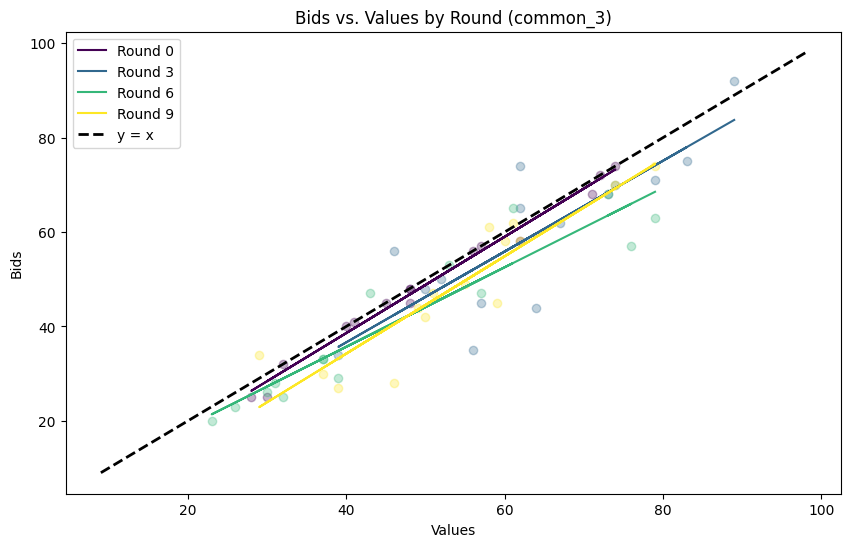

Processing common_4 from /Users/avshah/P_llm_auctions/llm-auction/experiment_logs/V10/common_spsb_4


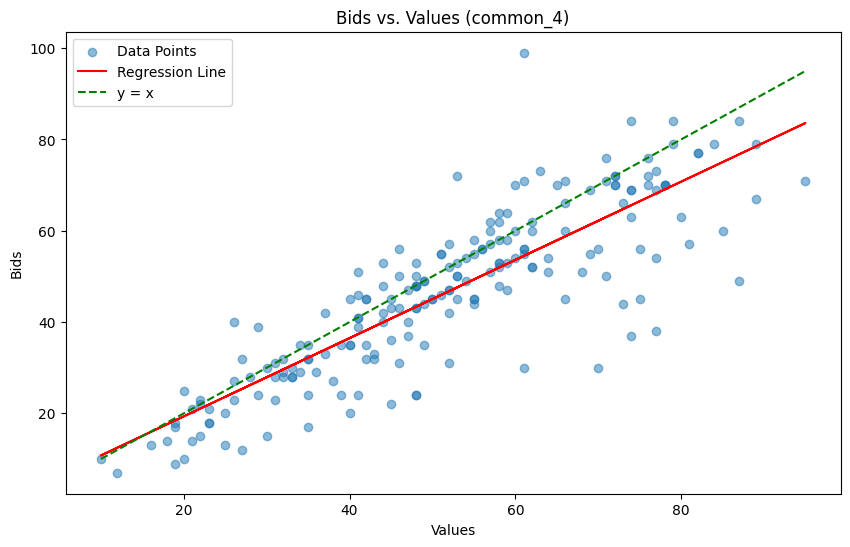

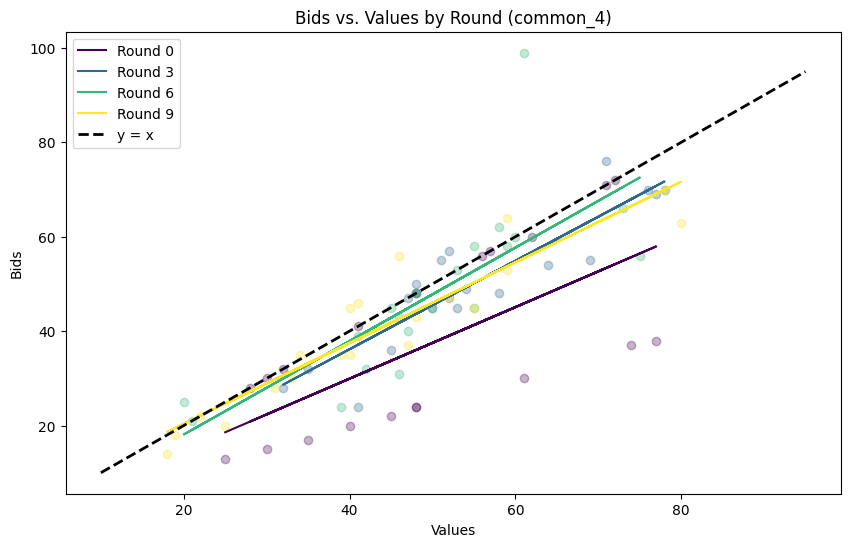

Processing common_5 from /Users/avshah/P_llm_auctions/llm-auction/experiment_logs/V10/common_spsb_5


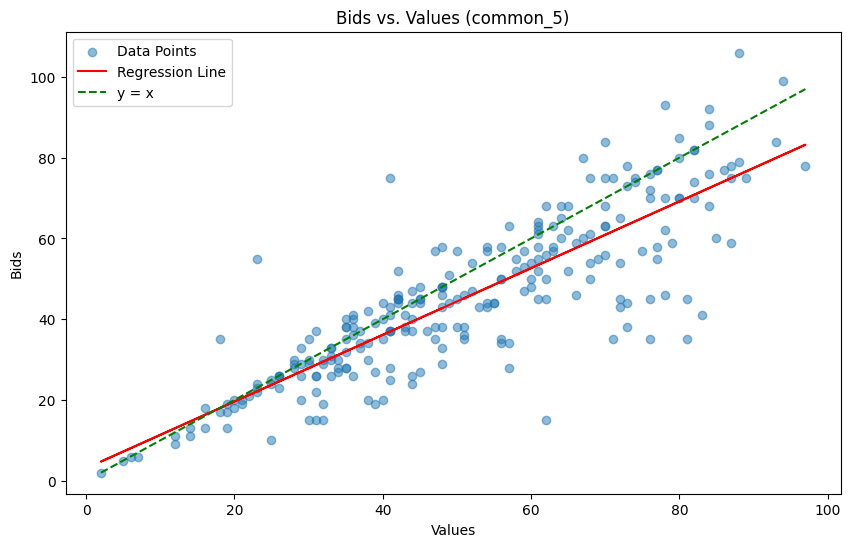

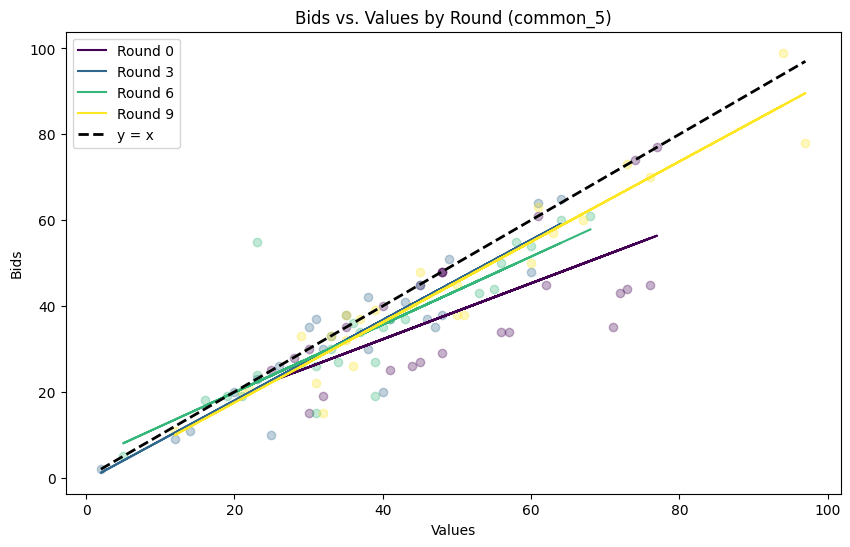

Processing common_6 from /Users/avshah/P_llm_auctions/llm-auction/experiment_logs/V10/common_spsb_6


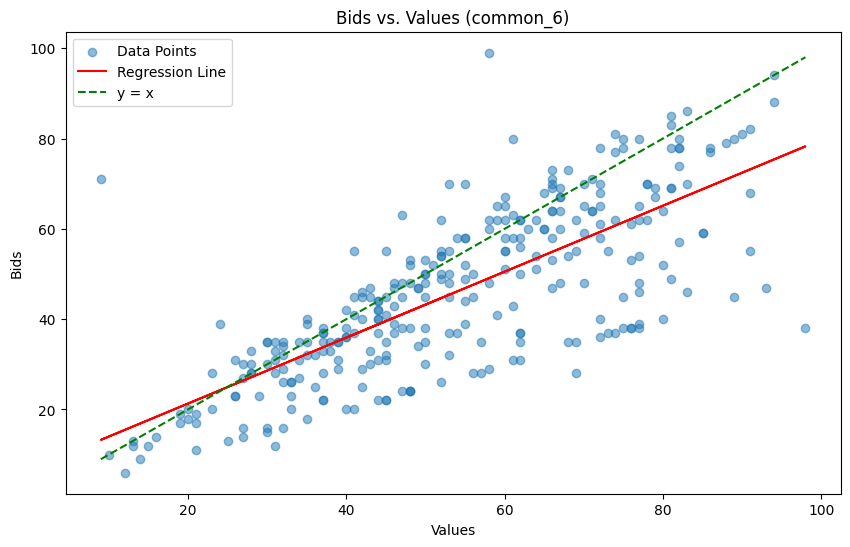

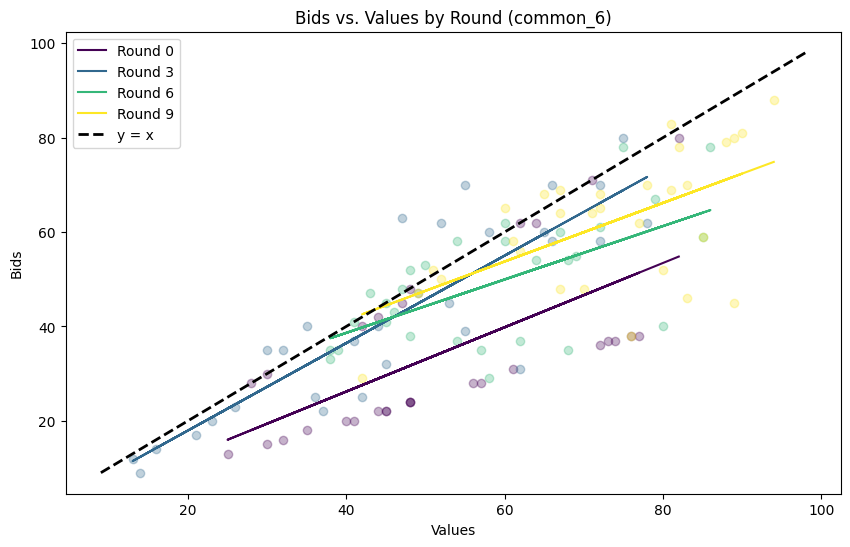

In [6]:
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import skew, skewtest
import warnings

warnings.filterwarnings('ignore', message='use_inf_as_na option is deprecated')

# --- Helper Functions for Data Aggregation ---

def extract_bid_value_pairs(row):
    """Extract bid and value lists from a row."""
    values = row.get("Values", [])
    bids = row.get("Bids", [])
    return values, bids

def aggregate_bid_value_pairs(df):
    """
    Aggregates bid and value pairs across all rows.
    
    Returns:
        X: numpy array of values.
        y: numpy array of bids.
    """
    bid_values = []
    bids = []
    for _, row in df.iterrows():
        values, bid_list = extract_bid_value_pairs(row)
        for value, bid in zip(values, bid_list):
            bid_values.append(value)
            bids.append(bid)
    return np.array(bid_values), np.array(bids)

# --- Original Plotting Functions ---

def plot_bid_value(df, label=""):
    """
    Plots bid vs. value along with a regression line and the y = x reference line.
    """
    X, y = aggregate_bid_value_pairs(df)
    if len(X) == 0:
        print(f"No bid-value data for {label}.")
        return
    X_with_const = sm.add_constant(X)
    model = sm.OLS(y, X_with_const).fit()
    regression_line = model.predict(X_with_const)
    
    x_range = np.linspace(X.min(), X.max(), 100)
    y_line = x_range
    
    plt.figure(figsize=(10,6))
    plt.scatter(X, y, alpha=0.5, label="Data Points")
    plt.plot(X, regression_line, color='red', label="Regression Line")
    plt.plot(x_range, y_line, color='green', linestyle='dashed', label="y = x")
    plt.xlabel("Values")
    plt.ylabel("Bids")
    plt.title(f"Bids vs. Values ({label})")
    plt.legend()
    plt.show()

def plot_by_round(df, step=5, label=""):
    """
    Plots bid-value pairs and regression lines for selected rounds.
    """
    rounds_sorted = sorted(df["Round"].dropna().unique())
    if not rounds_sorted:
        print(f"No rounds found for {label}.")
        return
    selected_rounds = rounds_sorted[::step]
    plt.figure(figsize=(10,6))
    colors = plt.cm.viridis(np.linspace(0, 1, len(selected_rounds)))
    for round_num, color in zip(selected_rounds, colors):
        group = df[df["Round"] == round_num]
        bid_values = []
        bids = []
        for _, row in group.iterrows():
            values, bid_list = extract_bid_value_pairs(row)
            for value, bid in zip(values, bid_list):
                bid_values.append(value)
                bids.append(bid)
        if len(bid_values) == 0:
            continue
        X = np.array(bid_values)
        y_vals = np.array(bids)
        X_with_const = sm.add_constant(X)
        model = sm.OLS(y_vals, X_with_const).fit()
        regression_line = model.predict(X_with_const)
        plt.scatter(X, y_vals, color=color, alpha=0.3)
        plt.plot(X, regression_line, color=color, label=f"Round {round_num}")
    overall_X, _ = aggregate_bid_value_pairs(df)
    if len(overall_X) > 0:
        x_range_all = np.linspace(overall_X.min(), overall_X.max(), 100)
        plt.plot(x_range_all, x_range_all, color='black', linestyle='dashed', linewidth=2, label="y = x")
    plt.xlabel("Values")
    plt.ylabel("Bids")
    plt.title(f"Bids vs. Values by Round ({label})")
    plt.legend()
    plt.show()

def plot_percent_error(df, label=""):
    """
    Computes and plots the average percent error (bid - value relative to value) by round.
    """
    def calculate_percent_error(row):
        errors = []
        values = row.get("Values", [])
        bids = row.get("Bids", [])
        for value, bid in zip(values, bids):
            if value != 0:
                errors.append((bid - value) / value)
            else:
                errors.append(np.nan)
        return errors
    
    df = df.copy()
    df["Percent Errors"] = df.apply(calculate_percent_error, axis=1)
    expanded_df = df.explode("Percent Errors")
    grouped = expanded_df.groupby("Round")["Percent Errors"].agg(["mean", "std"]).reset_index()
    plt.figure(figsize=(10,6))
    plt.errorbar(grouped["Round"], grouped["mean"], yerr=grouped["std"], fmt='o-', capsize=5, label="Avg Percent Error")
    plt.axhline(y=0, color='black', linestyle='dashed', linewidth=1)
    plt.xlabel("Round")
    plt.ylabel("Average Percent Error")
    plt.title(f"Average Percent Error by Round ({label})")
    plt.legend()
    plt.show()


def plot_bid_value_subplot(ax, df, label):
    """
    Helper function to plot bid vs. value on a given subplot (ax).
    """
    X, y = aggregate_bid_value_pairs(df)
    if len(X) == 0:
        ax.set_title(f"No Data for {label}")
        return
    
    X_with_const = sm.add_constant(X)
    model = sm.OLS(y, X_with_const).fit()
    regression_line = model.predict(X_with_const)

    x_range = np.linspace(X.min(), X.max(), 100)
    y_line = x_range

    ax.scatter(X, y, alpha=0.5, label="Data Points")
    ax.plot(X, regression_line, color='red', label="Regression Line")
    ax.plot(x_range, y_line, color='green', linestyle='dashed', label="y = x")
    ax.set_xlabel("Values")
    ax.set_ylabel("Bids")
    ax.set_title(f"Bids vs. Values ({label})")
    ax.legend()

# --- Additional Plot: Histogram of Bid - Value ---

def plot_bid_value_diff_histogram(df, label=""):
    """
    Plots a histogram of the differences (bid - value) for all bid-value pairs.
    """
    differences = []
    for _, row in df.iterrows():
        values, bid_list = extract_bid_value_pairs(row)
        for value, bid in zip(values, bid_list):
            differences.append(bid - value)
    if len(differences) == 0:
        print(f"No bid-value differences to plot for {label}.")
        return
    plt.figure(figsize=(10,6))
    sns.histplot(differences, bins=20, kde=True, color='skyblue')
    plt.xlabel("Bid - Value")
    plt.xlim(-60,60)
    plt.ylabel("Frequency")
    plt.title(f"Histogram of Bid - Value ({label})")
    plt.show()

# --- Data Ingestion Functions ---

def create_dataframe(json_files, exp_name):
    """
    Processes multiple JSON files into a single DataFrame for an intervention experiment.
    """
    all_rounds = []
    bidder_mapping = {
        'Bidder Andy': 0, 'Bidder Betty': 1, 'Bidder Charles': 2,
        'Bidder David': 3, 'Bidder Ethel': 4, 'Bidder Florian': 5
    }
    for file_idx, file in enumerate(json_files):
        try:
            with open(file, 'r') as f:
                data = json.load(f)
        except Exception as e:
            print(f"Error reading {file}: {e}")
            continue
        for round_key, round_data in data.items():
            if round_key.startswith('round_'):
                winner_name = round_data['history']['winner']['winner']
                winner_index = bidder_mapping.get(winner_name, None)
                try:
                    bids = [int(bid['bid']) for bid in round_data['history']['bidding history']]
                except Exception as e:
                    print(f"Error processing bids in {file}: {e}")
                    bids = []
                round_dict = {
                    'exp_name': exp_name,
                    'file_id': file_idx,
                    'Round': round_data.get('round', None),
                    'Values': round_data.get('value', []),
                    'Bids': bids,
                    'Winner Index': winner_index,
                    'Winner Name': winner_name,
                    'Realized Common Value': round_data.get('common', 'No common value'),
                    'Bid Paid by Winner': int(round_data['history']['winner'].get('price', 0)),
                    'Winner Total Profit': (round_data['profit'][winner_index]
                                            if (winner_index is not None and 
                                                'profit' in round_data and 
                                                len(round_data['profit']) > winner_index)
                                            else None)
                }
                all_rounds.append(round_dict)
    return pd.DataFrame(all_rounds)

def process_intervention_experiment(exp_name, directory):
    """
    Automatically discovers JSON files in the specified directory and creates a DataFrame.
    """
    pattern = os.path.join(directory, "*.json")
    json_files = glob.glob(pattern)
    if not json_files:
        print(f"No JSON files found in directory: {directory}")
        return None
    return create_dataframe(json_files, exp_name)

# --- Main Execution ---

def main():
    """
    Defines the intervention experiments, processes each experiment,
    generates the original plots, an extra histogram of bid-value differences,
    and then compiles and prints a summary table of regression and skew tests.
    """
    base_dir = '/Users/avshah/P_llm_auctions/llm-auction/experiment_logs/V10'
    interventions = {
        # "private_first": "private_first_price",
        # "private_second": "private_second_price",
        # "private_third": "private_third_price",
        # "private_all_pay": "private_all_pay", 
        # "menu_intervention": "intervention_menu",
        # "proxy_intervention": "intervention_proxy_breitmoser",
        # "nash_intervention": "intervention_nash_deviation",
        # "dominant_strat_intervention": "intervention_NE_strat_reveal",
        # "wrong_strat_intervention": "intervention_wrong_strat_reveal",
        # "risk_intervention": "intervention_risk_neutrality",
        "common_2" : "common_spsb_2",
        "common_3" : "common_spsb_3",
        "common_4" : "common_spsb_4",
        "common_5" : "common_spsb_5",
        "common_6" : "common_spsb_6"

    }
    
    all_dfs = {}
    
    # Process each experiment and generate plots.
    for exp_name, subdir in interventions.items():
        directory = os.path.join(base_dir, subdir)
        print(f"Processing {exp_name} from {directory}")
        df = process_intervention_experiment(exp_name, directory)
        if df is None:
            continue
        all_dfs[exp_name] = df
        
        # Generate the original plots.
        plot_bid_value(df, label=exp_name)
        plot_by_round(df, step=3, label=exp_name)
        # plot_percent_error(df, label=exp_name)
        
        # Generate additional histogram of bid - value differences.
        # plot_bid_value_diff_histogram(df, label=exp_name)
    
    # # --- Define Experiments to Include in the Panel ---
    # selected_experiments = [
    #     "menu_intervention", "proxy_intervention", "nash_intervention",
    #     "dominant_strat_intervention", "wrong_strat_intervention", "risk_intervention"
    # ]

    # # --- Create the Panel Plot ---
    # fig, axes = plt.subplots(2, 3, figsize=(18, 12))  # 2 rows, 3 columns

    # for ax, exp_name in zip(axes.flatten(), selected_experiments):
    #     if exp_name in all_dfs:
    #         plot_bid_value_subplot(ax, all_dfs[exp_name], label=exp_name)

    # plt.tight_layout()
    # # plt.savefig("Figs/bid_value_panel.png", dpi=300)  # Save for LaTeX
    # plt.show()

    # # Compile and print the summary table of regression and skew tests.
    # results_table = report_results_table(all_dfs)
    # print("Regression and Skewness Test Results:")
    # print(results_table.to_string(index=False))
    
    return all_dfs

if __name__ == "__main__":
    all_dfs = main()
    all_dfs


In [9]:
all_dfs["common_6"]

,exp_name,file_id,Round,Values,Bids,Winner Index,Winner Name,Realized Common Value,Bid Paid by Winner,Winner Total Profit
0,common_6,0,0,"[40, 71, 41, 61, 76, 42]","[20, 71, 20, 31, 38, 40]",1,Bidder Betty,59,40,19.0
1,common_6,0,1,"[47, 32, 31, 53, 19, 23]","[24, 34, 31, 37, 19, 28]",3,Bidder David,36,34,2.0
2,common_6,0,2,"[50, 41, 52, 77, 53, 74]","[50, 45, 54, 54, 32, 62]",5,Bidder Florian,60,54,6.0
3,common_6,0,3,"[47, 58, 66, 36, 55, 53]","[63, 60, 58, 25, 39, 45]",0,Bidder Andy,46,60,-14.0
4,common_6,0,4,"[21, 50, 20, 47, 34, 15]","[11, 50, 18, 38, 27, 12]",1,Bidder Betty,30,38,-8.0
5,common_6,0,5,"[53, 79, 77, 91, 64, 77]","[55, 69, 48, 82, 51, 65]",3,Bidder David,73,69,4.0
6,common_6,0,6,"[48, 38, 54, 72, 39, 43]","[52, 33, 58, 61, 35, 47]",3,Bidder David,54,58,-4.0
7,common_6,0,7,"[56, 59, 55, 60, 52, 62]","[50, 65, 52, 51, 49, 58]",1,Bidder Betty,51,58,-7.0
8,common_6,0,8,"[52, 65, 82, 44, 67, 45]","[54, 60, 78, 37, 67, 35]",2,Bidder Charles,64,67,-3.0
9,common_6,0,9,"[94, 61, 71, 88, 60, 83]","[88, 58, 64, 79, 65, 70]",0,Bidder Andy,77,79,-2.0
